# Feature Store Dataset EDA

Analyze the engineered weekly dataset from:
- `data/weekly_model_dataset.parquet`

Goals:
- inspect target behavior
- explore correlations between features and targets
- visualize potential predictive signal for claim occurrence and claim type


In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('..').resolve() / 'data'
DATA_PATH = BASE_DIR / 'weekly_model_dataset.parquet'


In [18]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing {DATA_PATH}. Run prototype/feature_engineering.ipynb first.')

df = pd.read_parquet(DATA_PATH).copy()
if 'week_start' in df.columns:
    df['week_start'] = pd.to_datetime(df['week_start'], errors='coerce')

print('shape:', df.shape)
print('date range:', df['week_start'].min() if 'week_start' in df.columns else 'n/a', '->', df['week_start'].max() if 'week_start' in df.columns else 'n/a')
print('columns:', len(df.columns))
df.head()


shape: (53985, 24)
date range: 2023-10-02 00:00:00 -> 2024-12-23 00:00:00
columns: 24


,resident_id,facility_id,week_start,week_end,resident_age,BP - Systolic_mean,BP - Systolic_std,Blood Sugar_mean,Blood Sugar_std,O2 sats_mean,...,Pulse_std,Respiration_mean,Respiration_std,Temperature_mean,Temperature_std,Weight_mean,Weight_std,dystolic_value_mean,target_claim_next_week,target_claim_type_next_week
0,000d4288-4983-5512-b4e8-bf5efa8e20ef,75713da7-fe55-5b40-b6db-01ad1c35a615,2024-03-18,2024-03-24,62.847365,129.230769,9.337682,NaN,NaN,94.000000,...,7.141428,18.153846,0.688737,97.753846,0.352646,254.2,36.48671,75.384615,0,NoClaim
1,000d4288-4983-5512-b4e8-bf5efa8e20ef,75713da7-fe55-5b40-b6db-01ad1c35a615,2024-03-25,2024-03-31,62.866530,129.944444,7.132958,NaN,NaN,96.555556,...,6.500880,18.277778,0.669113,97.911111,0.443103,228.2,NaN,73.833333,0,NoClaim
2,000d4288-4983-5512-b4e8-bf5efa8e20ef,75713da7-fe55-5b40-b6db-01ad1c35a615,2024-04-01,2024-04-07,62.885695,123.850000,11.485804,NaN,NaN,96.050000,...,8.663900,17.950000,0.510418,97.760000,0.434560,NaN,NaN,75.450000,0,NoClaim
3,000d4288-4983-5512-b4e8-bf5efa8e20ef,75713da7-fe55-5b40-b6db-01ad1c35a615,2024-04-08,2024-04-14,62.904860,127.200000,9.361736,NaN,NaN,97.000000,...,4.716526,17.789474,0.418854,97.840000,0.395235,223.0,NaN,75.150000,0,NoClaim
4,000d4288-4983-5512-b4e8-bf5efa8e20ef,75713da7-fe55-5b40-b6db-01ad1c35a615,2024-04-15,2024-04-21,62.924025,124.190476,10.604806,NaN,NaN,96.523810,...,8.492013,17.952381,0.384212,98.047619,0.422633,NaN,NaN,73.857143,0,NoClaim


## Data Quality and Target Overview


In [19]:
target_cols = ['target_claim_next_week', 'target_claim_type_next_week']
for c in target_cols:
    if c not in df.columns:
        raise ValueError(f'Missing expected target column: {c}')

summary = {
    'rows': len(df),
    'unique_residents': df['resident_id'].nunique() if 'resident_id' in df.columns else np.nan,
    'weeks': df['week_start'].nunique() if 'week_start' in df.columns else np.nan,
    'target_claim_prevalence': df['target_claim_next_week'].mean(),
    'target_claim_positive_rows': int(df['target_claim_next_week'].sum()),
    'target_type_classes': df['target_claim_type_next_week'].nunique(dropna=True),
}

pd.Series(summary)


rows                          53985.000000
unique_residents               2559.000000
weeks                            65.000000
target_claim_prevalence           0.035343
target_claim_positive_rows     1908.000000
target_type_classes               7.000000
dtype: float64

In [20]:
# Missingness snapshot (top 25)
missing = (df.isna().mean() * 100).sort_values(ascending=False).head(25)
missing


Weight_std                     94.433639
Blood Sugar_std                84.141891
Blood Sugar_mean               82.102436
Respiration_std                77.056590
O2 sats_std                    72.823933
Weight_mean                    72.333055
Temperature_std                71.501343
Respiration_mean               63.186070
Pulse_std                      62.850792
O2 sats_mean                   61.730110
BP - Systolic_std              61.276280
Temperature_mean               59.629527
Pulse_mean                     51.603223
BP - Systolic_mean             50.932666
dystolic_value_mean            50.932666
Pain Level_std                 42.600722
Pain Level_mean                41.198481
resident_age                    0.098175
target_claim_next_week          0.000000
resident_id                     0.000000
facility_id                     0.000000
week_end                        0.000000
week_start                      0.000000
target_claim_type_next_week     0.000000
dtype: float64

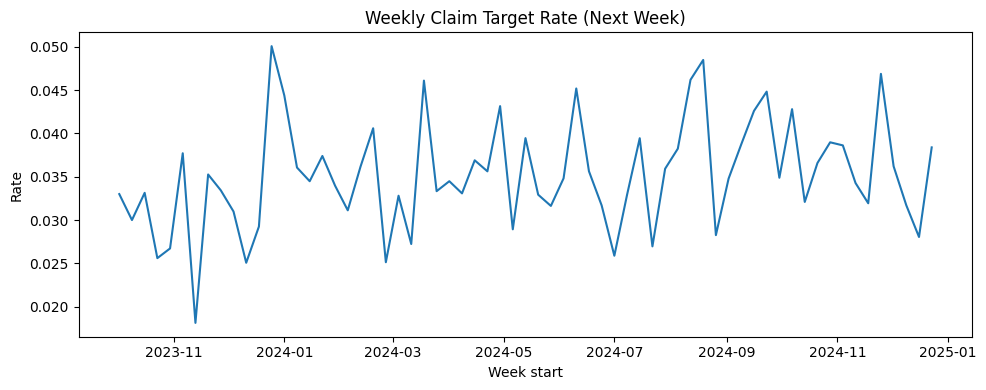

In [21]:
# Target distribution over time
if 'week_start' in df.columns:
    weekly = (
        df.groupby('week_start', as_index=False)
        .agg(
            rows=('target_claim_next_week', 'size'),
            claim_rate=('target_claim_next_week', 'mean')
        )
        .sort_values('week_start')
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(weekly['week_start'], weekly['claim_rate'])
    ax.set_title('Weekly Claim Target Rate (Next Week)')
    ax.set_xlabel('Week start')
    ax.set_ylabel('Rate')
    plt.tight_layout()
    plt.show()


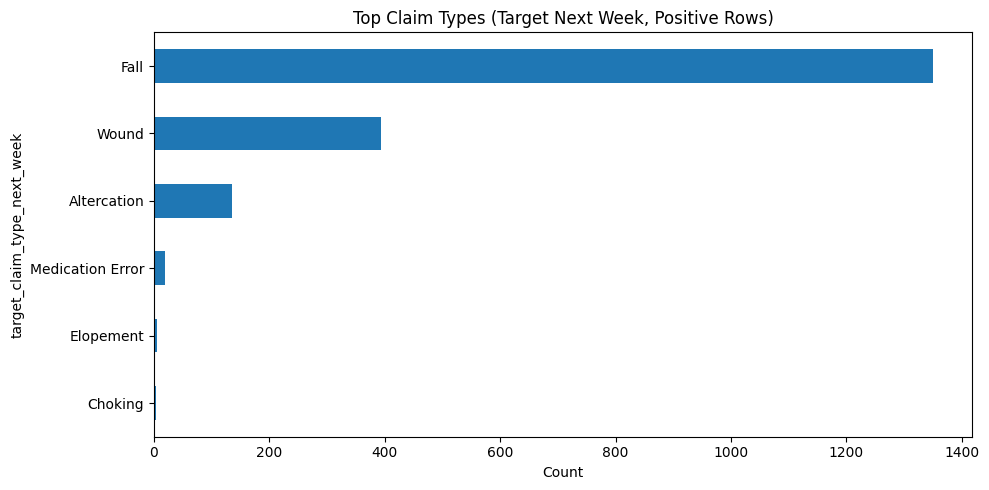

In [22]:
# Claim type distribution (for positive target rows)
pos = df[df['target_claim_next_week'] == 1].copy()
if len(pos):
    type_counts = pos['target_claim_type_next_week'].fillna('Unknown').value_counts().head(20)

    fig, ax = plt.subplots(figsize=(10, 5))
    type_counts.sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Top Claim Types (Target Next Week, Positive Rows)')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

    type_counts


## Correlations With Binary Target

For numeric features, compute Pearson correlation with `target_claim_next_week`.


In [23]:
exclude = {
    'target_claim_next_week',
    'target_claim_type_next_week',
}

num_cols = [
    c for c in df.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
]

corr = df[num_cols + ['target_claim_next_week']].corr(numeric_only=True)['target_claim_next_week'].drop('target_claim_next_week')

corr_rank = corr.abs().sort_values(ascending=False)
print('Numeric features evaluated:', len(num_cols))

# Top positive / negative linear relationships
top_pos = corr.sort_values(ascending=False).head(20)
top_neg = corr.sort_values(ascending=True).head(20)

display(top_pos)
display(top_neg)


Numeric features evaluated: 18


dystolic_value_mean    0.018494
resident_age           0.014435
Pain Level_std         0.012870
Blood Sugar_std        0.010674
Pulse_mean             0.009919
BP - Systolic_std      0.002106
Pulse_std             -0.000119
O2 sats_std           -0.001280
Respiration_std       -0.001777
Temperature_mean      -0.002940
Respiration_mean      -0.002993
Blood Sugar_mean      -0.003073
BP - Systolic_mean    -0.004806
Pain Level_mean       -0.005029
Temperature_std       -0.005131
O2 sats_mean          -0.007912
Weight_std            -0.009416
Weight_mean           -0.011026
Name: target_claim_next_week, dtype: float64

Weight_mean           -0.011026
Weight_std            -0.009416
O2 sats_mean          -0.007912
Temperature_std       -0.005131
Pain Level_mean       -0.005029
BP - Systolic_mean    -0.004806
Blood Sugar_mean      -0.003073
Respiration_mean      -0.002993
Temperature_mean      -0.002940
Respiration_std       -0.001777
O2 sats_std           -0.001280
Pulse_std             -0.000119
BP - Systolic_std      0.002106
Pulse_mean             0.009919
Blood Sugar_std        0.010674
Pain Level_std         0.012870
resident_age           0.014435
dystolic_value_mean    0.018494
Name: target_claim_next_week, dtype: float64

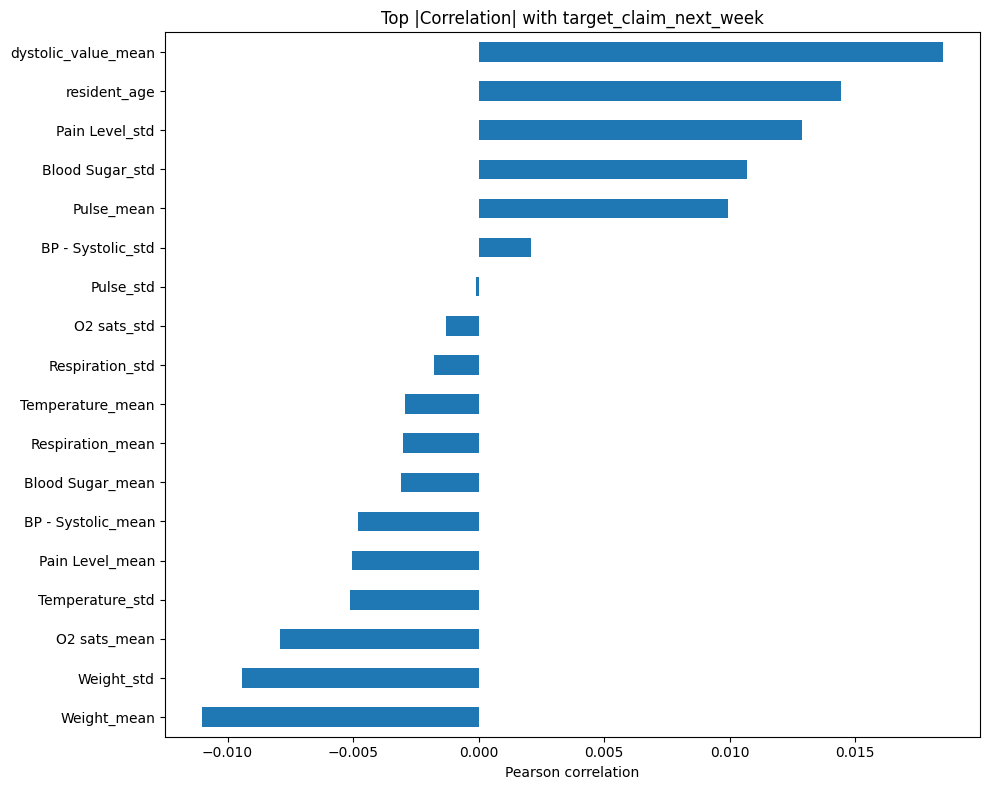

In [24]:
# Correlation bar chart (top absolute)
top_abs = corr.abs().sort_values(ascending=False).head(25).index
plot_df = corr.loc[top_abs].sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
plot_df.plot(kind='barh', ax=ax)
ax.set_title('Top |Correlation| with target_claim_next_week')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


## Feature Distributions by Target Class


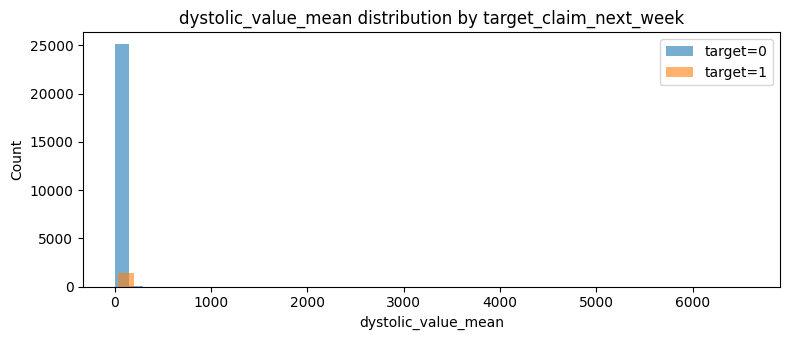

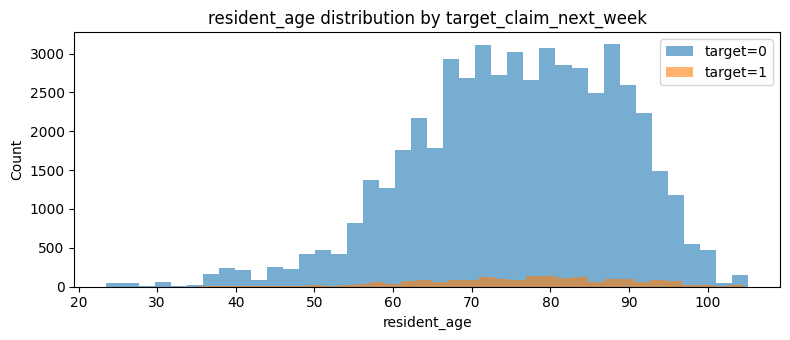

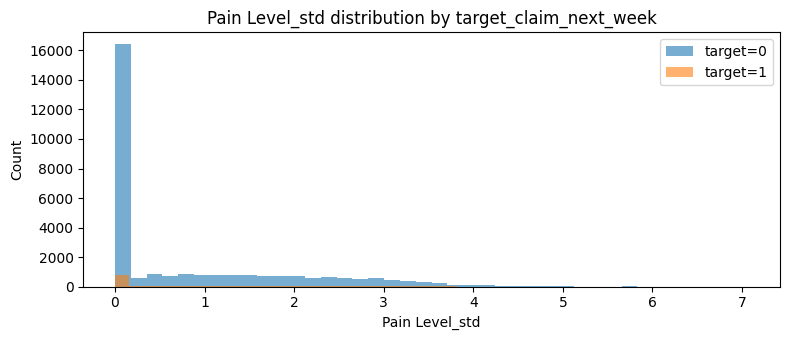

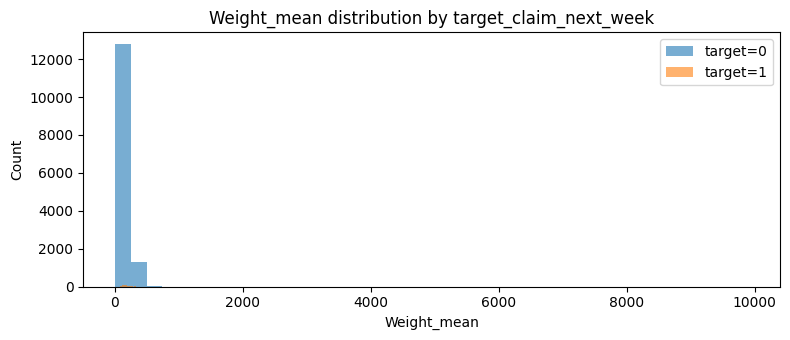

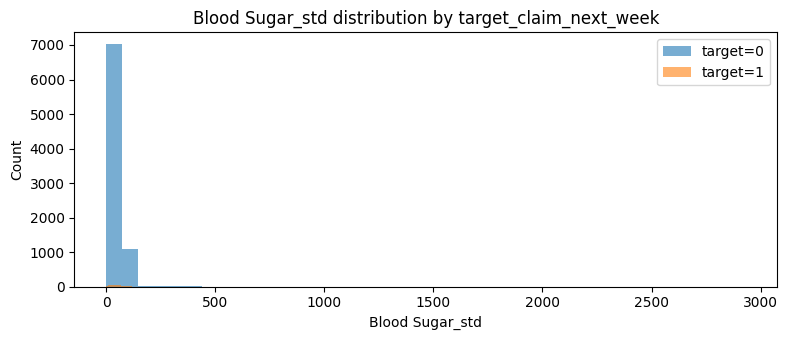

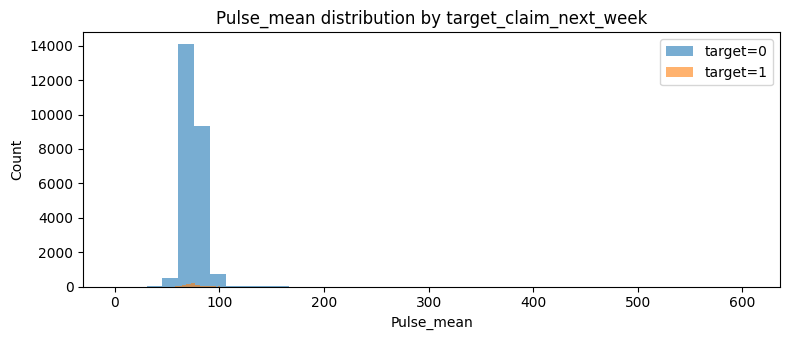

In [25]:
# Show class-conditional distributions for strongest correlated numeric features
top_features = corr.abs().sort_values(ascending=False).head(6).index.tolist()

for feat in top_features:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(df.loc[df['target_claim_next_week'] == 0, feat].dropna(), bins=40, alpha=0.6, label='target=0')
    ax.hist(df.loc[df['target_claim_next_week'] == 1, feat].dropna(), bins=40, alpha=0.6, label='target=1')
    ax.set_title(f'{feat} distribution by target_claim_next_week')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [12]:
# Lift-style analysis with deciles for top numeric feature
if len(top_features):
    f = top_features[0]
    d = df[[f, 'target_claim_next_week']].dropna().copy()
    if d[f].nunique() > 10:
        d['decile'] = pd.qcut(d[f], q=10, duplicates='drop')
        lift = d.groupby('decile', as_index=False)['target_claim_next_week'].mean()

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(lift['decile'].astype(str), lift['target_claim_next_week'], marker='o')
        ax.set_title(f'Claim Rate by {f} decile')
        ax.set_xlabel('Decile')
        ax.set_ylabel('Claim rate')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()


## Categorical Signal Checks

Compare categorical feature rates against target.


In [26]:
cat_candidates = [c for c in df.columns if df[c].dtype == 'object']
cat_candidates = [c for c in cat_candidates if c not in ['target_claim_type_next_week']]

# Keep low/medium cardinality columns for readable plots
cat_candidates = [c for c in cat_candidates if df[c].nunique(dropna=True) <= 25]

print('Categorical columns scanned:', len(cat_candidates))
cat_candidates[:20]


Categorical columns scanned: 0


[]

In [27]:
# Plot top categorical columns by difference in claim rate
cat_signal_rows = []
for c in cat_candidates:
    t = (
        df[[c, 'target_claim_next_week']]
        .copy()
        .assign(**{c: lambda x: x[c].fillna('Unknown').astype(str)})
        .groupby(c, as_index=False)
        .agg(rate=('target_claim_next_week', 'mean'), n=('target_claim_next_week', 'size'))
    )
    if len(t) < 2:
        continue
    span = t['rate'].max() - t['rate'].min()
    cat_signal_rows.append((c, span, len(t)))

cat_signal = pd.DataFrame(cat_signal_rows, columns=['feature', 'rate_span', 'levels']).sort_values('rate_span', ascending=False)
cat_signal.head(10)


,feature,rate_span,levels


In [28]:
# Visualize up to top 3 categorical features with strongest rate separation
for c in cat_signal.head(3)['feature'].tolist():
    t = (
        df[[c, 'target_claim_next_week']]
        .copy()
        .assign(**{c: lambda x: x[c].fillna('Unknown').astype(str)})
        .groupby(c, as_index=False)
        .agg(rate=('target_claim_next_week', 'mean'), n=('target_claim_next_week', 'size'))
        .sort_values('rate', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(t[c], t['rate'])
    ax.set_title(f'Claim rate by {c}')
    ax.set_xlabel(c)
    ax.set_ylabel('Claim rate')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


## Correlation With Claim Type (When Claim Occurs)

Explore numeric relationships with specific claim types among positive-target rows.


In [16]:
pos = df[df['target_claim_next_week'] == 1].copy()
if len(pos) == 0:
    print('No positive claim rows found.')
else:
    top_types = pos['target_claim_type_next_week'].fillna('Unknown').value_counts().head(5).index.tolist()
    print('Top types used for one-vs-rest signal check:', top_types)

    rows = []
    eval_num_cols = [c for c in num_cols if pos[c].notna().sum() > 20]

    for t in top_types:
        y = (pos['target_claim_type_next_week'] == t).astype(int)
        for c in eval_num_cols:
            x = pos[c]
            mask = x.notna()
            if mask.sum() < 20:
                continue
            corr_t = np.corrcoef(x[mask], y[mask])[0, 1]
            if np.isfinite(corr_t):
                rows.append((t, c, corr_t, abs(corr_t)))

    type_corr = pd.DataFrame(rows, columns=['claim_type', 'feature', 'corr', 'abs_corr'])
    if len(type_corr):
        type_corr = type_corr.sort_values(['claim_type', 'abs_corr'], ascending=[True, False])
        display(type_corr.groupby('claim_type').head(10))


Top types used for one-vs-rest signal check: ['Fall', 'Wound', 'Altercation', 'Medication Error', 'Elopement']


/home/rubim/.pyenv/versions/3.8.10/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/rubim/.pyenv/versions/3.8.10/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/rubim/.pyenv/versions/3.8.10/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/rubim/.pyenv/versions/3.8.10/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,claim_type,feature,corr,abs_corr
73,Altercation,transfer_count_sum,0.184905,0.184905
52,Altercation,resident_age,-0.150344,0.150344
55,Altercation,Blood Sugar_mean,0.129441,0.129441
76,Altercation,had_transfer_week,0.105315,0.105315
74,Altercation,had_injury_week,-0.064669,0.064669
56,Altercation,Blood Sugar_std,0.063065,0.063065
72,Altercation,admission_count_sum,0.061011,0.061011
64,Altercation,Respiration_std,0.054628,0.054628
71,Altercation,injury_count_sum,-0.051306,0.051306
67,Altercation,Weight_mean,0.048984,0.048984


## Business-Oriented Findings Checklist

Use this notebook to answer:
- Which features are most linearly associated with next-week claim risk?
- Which features separate target classes in distribution plots?
- Which resident segments (categorical slices) show elevated claim rates?
- Which features may help differentiate the most common claim types?
